In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import warnings
from pathlib import Path
from datetime import timedelta
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import tempfile
import shutil
from tqdm import tqdm

import rasterio
import rioxarray
from rasterio.transform import rowcol
import geopandas as gpd
from shapely.geometry import Point

from pyproj import CRS, Transformer, Geod
import geopy.distance as distance

from PIL import Image as PILImage
from IPython.display import Image

# CyFi imports
from cyfi.pipeline import CyFiPipeline
from cyfi.config import FeaturesConfig, CyFiModelConfig
from cyfi.data.features import generate_all_features
from cyfi.cli import DEFAULT_MODEL_PATH

# images in excel
import openpyxl
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as OpenPyXLImage
from PIL import Image as PILImage  # Rename to avoid conflict with openpyxl
import io


import planetary_computer as pc
from pystac_client import Client
# Need the Planetary Computer client (pc) for signing assets, assuming it's imported elsewhere
# If not, add: import pystac_client; import planetary_computer as pc 

## Suppress warnings
#warnings.filterwarnings('ignore', message='The given provided crs is not equal to the raster crs')


C:\Users\KostasPikounis\anaconda3\envs\AMFITRITE\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_bounding_box(latitude, longitude, meter_buffer=50000):
    """
    Given a latitude, longitude, and buffer in meters, returns a bounding
    box [min_lon, min_lat, max_lon, max_lat] around the point.
    """
    g = Geod(ellps='WGS84')
    # Forward calculation: (lon, lat, back_az)
    lon_west, _, _ = g.fwd(longitude, latitude, 270, meter_buffer)
    _, lat_south, _ = g.fwd(longitude, latitude, 180, meter_buffer)
    lon_east, _, _ = g.fwd(longitude, latitude, 90, meter_buffer)
    _, lat_north, _ = g.fwd(longitude, latitude, 0, meter_buffer)
    return [lon_west, lat_south, lon_east, lat_north]

def get_date_range(date, time_buffer_days=15):
    """Get a date range to search for in the planetary computer based
    on a sample's date. The time range will include the sample date
    and time_buffer_days days prior

    Returns a string"""
    datetime_format = "%Y-%m-%d"
    range_start = pd.to_datetime(date) - timedelta(days=time_buffer_days)
    range_end = pd.to_datetime(date) + timedelta(days=time_buffer_days)
    date_range = f"{range_start.strftime(datetime_format)}/{range_end.strftime(datetime_format)}"

    return date_range

def extract_and_save_tile(
    item,
    points_df,
    initial_pixel_size=100,
    save_data=False,
    output_path=None
):
    print("--- Starting Tile Extraction and Processing ---")
    
    # 1. Setup
    target_crs = CRS.from_string(item.properties["proj:code"])
    center_lat = points_df['lat'].mean()
    center_lon = points_df['lon'].mean()
    print(f"Center Point (Lat/Lon): ({center_lat:.4f}, {center_lon:.4f})")
    
    # Calculate bounding box in UTM
    points_gdf = gpd.GeoDataFrame(
        points_df, 
        geometry=gpd.points_from_xy(points_df.lon, points_df.lat), 
        crs=CRS.from_string("EPSG:4326")
    ).to_crs(target_crs)
    
    minx_points, miny_points, maxx_points, maxy_points = points_gdf.total_bounds
    center_x = (minx_points + maxx_points) / 2
    center_y = (miny_points + maxy_points) / 2
    
    initial_side_meters = initial_pixel_size * 10
    required_margin_meters = max(maxx_points - minx_points, maxy_points - miny_points) / 2
    final_margin_meters = max(initial_side_meters / 2, required_margin_meters)
    
    min_x_final = center_x - final_margin_meters
    max_x_final = center_x + final_margin_meters
    min_y_final = center_y - final_margin_meters
    max_y_final = center_y + final_margin_meters
    
    final_pixel_side = int((max_x_final - min_x_final) / 10)
    print(f"Final Tile Dimension (10m pixels): {final_pixel_side} x {final_pixel_side}")
    
    clip_bbox_utm = (min_x_final, min_y_final, max_x_final, max_y_final)
    transformer_latlon_to_utm = Transformer.from_crs(CRS.from_string("EPSG:4326"), target_crs, always_xy=True)
    
    # 2. Asset Clipping and ALIGNMENT
    band_gsd_map = {
        "B02": 10, "B03": 10, "B04": 10, "B08": 10, "visual": 10, "AOT": 10, "WVP": 60,
        "B05": 20, "B06": 20, "B07": 20, "B8A": 20, "SCL": 20, "B11": 20, "B12": 20,
        "B01": 60, "B09": 60
    }
    
    clipped_data = {}
    print("--- Clipping and Aligning Rasters ---")
    
    # 2a. Load Reference (B04)
    b04_href = pc.sign(item.assets["B04"].href)
    b04_ds = rioxarray.open_rasterio(b04_href)
    b04_clip = b04_ds.rio.clip_box(
        minx=clip_bbox_utm[0], miny=clip_bbox_utm[1], 
        maxx=clip_bbox_utm[2], maxy=clip_bbox_utm[3],
        crs=target_crs
    )
    b04_clip = b04_clip.isel(y=slice(0, final_pixel_side), x=slice(0, final_pixel_side))
    clipped_data["B04"] = b04_clip.squeeze() 
    print(f"Clipped B04 (Reference): Shape {b04_clip.shape}")

    # 2b. Align others
    for asset_key, gsd in band_gsd_map.items():
        if asset_key == "B04": continue
        
        asset_href = pc.sign(item.assets[asset_key].href)
        ds = rioxarray.open_rasterio(asset_href)
        
        ds_clip = ds.rio.clip_box(
            minx=clip_bbox_utm[0], miny=clip_bbox_utm[1], 
            maxx=clip_bbox_utm[2], maxy=clip_bbox_utm[3],
            crs=target_crs
        )

        resampling_method = rasterio.enums.Resampling.nearest if asset_key == "SCL" else rasterio.enums.Resampling.bilinear
        ds_aligned = ds_clip.rio.reproject_match(b04_clip, resampling=resampling_method)
        
        if asset_key != "visual":
            clipped_data[asset_key] = ds_aligned.squeeze()
        else:
             clipped_data[asset_key] = ds_aligned
        
        print(f"Clipped {asset_key}: Shape {ds_aligned.shape}")

    # --- SAVE RAW DATA (Unmodified) ---
    if save_data:
        output_dir = Path(output_path)
        output_dir.mkdir(parents=True, exist_ok=True)
        print("\n--- Saving RAW TIFFs ---")
        for key, da in clipped_data.items():
            da.rio.to_raster(output_dir / f"{key}_raw.tif")

    # --- 3. Calculate Indices (Scaled for Vis/Preview) ---
    print("--- Calculating Indices for Visualization ---")
    SCALE_FACTOR = 10000.0 
    
    b04_ref = (clipped_data["B04"] / SCALE_FACTOR).astype(np.float32)
    b05_ref = (clipped_data["B05"] / SCALE_FACTOR).astype(np.float32)
    b07_ref = (clipped_data["B07"] / SCALE_FACTOR).astype(np.float32)
    b08_ref = (clipped_data["B08"] / SCALE_FACTOR).astype(np.float32)
    
    sum_b8_b4 = b08_ref + b04_ref
    ndvi = (b08_ref - b04_ref) / sum_b8_b4.where(sum_b8_b4 != 0, np.nan) 
    
    sum_b7_b5 = b07_ref + b05_ref
    ndci = (b07_ref - b05_ref) / sum_b7_b5.where(sum_b7_b5 != 0, np.nan) 
    
    # Store indices for visualization
    vis_data = clipped_data.copy()
    vis_data["NDVI"] = ndvi
    vis_data["NDCI"] = ndci

    # --- 4. Save Visual Previews (WITH RED X MARKERS) ---
    if save_data:
        print("--- Saving Visual Previews (with markers) ---")
        
        # Prepare coordinates for plotting
        point_x, point_y = transformer_latlon_to_utm.transform(points_df.lon.values, points_df.lat.values)
        
        # Colormap setup
        colors = ['white', 'white', 'black', 'black', 'green', 'saddlebrown', 'lightblue', 'grey', 'grey', 'grey', 'grey']
        cmap_scl = ListedColormap(colors)
        bounds = np.arange(12)
        norm_scl = BoundaryNorm(bounds, cmap_scl.N)

        # Helper to save plot with markers
        def save_plot_with_points(da, key, cmap=None, norm=None, vmin=None, vmax=None, rgb=False):
            fig, ax = plt.subplots(figsize=(10, 10))
            
            extent = [da.x.min(), da.x.max(), da.y.min(), da.y.max()]
            
            if rgb:
                da.plot.imshow(ax=ax, rgb="band", robust=True)
            elif key == "SCL":
                ax.imshow(da.values, cmap=cmap, norm=norm, extent=extent, origin='upper')
            else:
                robust = True if vmin is None else False
                da.plot.imshow(ax=ax, cmap=cmap, robust=robust, add_colorbar=False, 
                               origin='upper', extent=extent, norm=norm, vmin=vmin, vmax=vmax)
            
            # OVERLAY RED X
            ax.scatter(point_x, point_y, c='red', s=100, marker='x', linewidths=2.5)
            ax.set_axis_off() # clean look
            
            plt.savefig(output_dir / f"{key}_preview.png", bbox_inches='tight')
            plt.close(fig)

        # Save all bands + indices
        for key in vis_data.keys():
            da = vis_data[key]
            
            if key == "visual":
                save_plot_with_points(da, key, rgb=True)
            elif key == "SCL":
                save_plot_with_points(da, key, cmap=cmap_scl, norm=norm_scl)
            elif key == "NDVI":
                save_plot_with_points(da, key, cmap="RdYlGn", vmin=-1, vmax=1)
            elif key == "NDCI":
                save_plot_with_points(da, key, cmap="jet", vmin=-1, vmax=1)
            else:
                # Default bands (grayscale)
                save_plot_with_points(da, key, cmap="gray")

        # Save metadata
        metadata = {
            "item_id": item.id,
            "uid":points_df.iloc[0]["uid"], 
            "abun":max(points_df["abun"].to_list()),
            "tile_size_10m_pixels": final_pixel_side,
            "date": item.properties["datetime"].split('T')[0],
            "center_lat": center_lat,
            "center_lon": center_lon,
            "points_data": points_df[['lat', 'lon']].to_dict('records')
        }
        with open(output_dir / "metadata.json", "w") as f:
            json.dump(metadata, f, indent=4)
            
        print(f"Data successfully saved to: {output_dir.resolve()}")

    # --- 5. LIVE VISUALIZATION ---
    print("\n--- Displaying Images ---")
    
    # Points for overlay (calculated above)
    assets_to_plot = {
        "visual": ("True Color (RGB)", None, None, False, None, None),
        "B04": ("Band 4 (Red)", "gray", None, True, None, None),
        "B08": ("Band 8 (NIR)", "gray", None, True, None, None),
        "SCL": ("Scene Classification (SCL)", cmap_scl, norm_scl, False, None, None),
        "NDVI": ("NDVI (Vegetation)", "RdYlGn", None, True, -1, 1),
        "NDCI": ("NDCI (Chlorophyll)", "jet", None, True, -1, 1) 
    }

    for key, (title, cmap, norm, add_colorbar, vmin, vmax) in assets_to_plot.items():
        da = vis_data[key]
        
        fig, ax = plt.subplots(figsize=(12, 12))
        extent = [da.x.min(), da.x.max(), da.y.min(), da.y.max()]
        
        if key == "visual":
            da.plot.imshow(ax=ax, rgb="band", robust=True)
        elif key == "SCL":
            ax.imshow(da.values, cmap=cmap, norm=norm, extent=extent, origin='upper')
        else:
            robust_setting = True if vmin is None else False
            da.plot.imshow(ax=ax, cmap=cmap, robust=robust_setting, add_colorbar=add_colorbar, 
                           origin='upper', extent=extent, norm=norm, vmin=vmin, vmax=vmax)

        ax.scatter(point_x, point_y, c='red', s=100, marker='x', linewidths=2.5)
        ax.set_title(f"{title}", fontsize=16)
        plt.show()


def predict_using_cyfi_pipeline(input_folder_path, date_str, metadata_filename="metadata.json"):
    input_dir = Path(input_folder_path).resolve()
    print(f"--- Starting CyFi Pipeline Integration (Cloud Threshold 7.5%): {input_dir} ---")

    # 1. Configuration
    features_config = FeaturesConfig()
    
    # Set Cloud Threshold to 7.5%
    CLOUD_THRESHOLD = 0.075 
    features_config.max_cloud_percent = CLOUD_THRESHOLD

    WINDOW_METERS = features_config.image_feature_meter_window 
    PIXEL_SIZE = 10
    WINDOW_PIXELS = WINDOW_METERS // PIXEL_SIZE 
    RADIUS_PIXELS = WINDOW_PIXELS // 2 

    # 2. Load Raw Raster Data & Metadata
    required_bands = features_config.use_sentinel_bands 
    data_store = {}
    
    # Load SCL (for geometry and cloud check)
    try:
        scl_da = rioxarray.open_rasterio(input_dir / "SCL_raw.tif").squeeze()
        data_store["SCL"] = scl_da.values
        height, width = scl_da.shape
        transform = scl_da.rio.transform()
        crs = scl_da.rio.crs
    except FileNotFoundError:
        print("Error: SCL_raw.tif not found. Run Part 1 first.")
        return

    # Load Metadata (to retrieve original reference points AND to be updated later)
    metadata_path = input_dir / metadata_filename
    metadata = {}
    original_points = []
    
    try:
        with open(metadata_path, "r") as f:
            metadata = json.load(f)
            original_points = metadata.get("points_data", [])
    except FileNotFoundError:
        print(f"Warning: {metadata_filename} not found. A new one will be created.")

    # Load other bands
    for band in required_bands:
        if band == "SCL": continue
        path = input_dir / f"{band}_raw.tif"
        if path.exists():
            data_store[band] = rioxarray.open_rasterio(path).squeeze().values
        else:
            data_store[band] = np.full((height, width), np.nan, dtype=np.float32)

    # 3. Generate Lattice Grid
    print("Generating 100m Lattice Grid...")
    GRID_STEP = 10 
    
    rows = np.arange(0, height, GRID_STEP)
    cols = np.arange(0, width, GRID_STEP)
    grid_rows, grid_cols = np.meshgrid(rows, cols, indexing='ij')
    grid_rows = grid_rows.flatten()
    grid_cols = grid_cols.flatten()
    
    valid_mask = (grid_rows < height) & (grid_cols < width)
    grid_rows = grid_rows[valid_mask]
    grid_cols = grid_cols[valid_mask]
    
    # Check water mask
    water_mask = (data_store["SCL"][grid_rows, grid_cols] == 6)
    target_rows = grid_rows[water_mask]
    target_cols = grid_cols[water_mask]
    
    initial_samples = len(target_rows)
    print(f"Identified {initial_samples} potential water points.")
    if initial_samples == 0: return

    # 4. Create Mock Cache Structure
    temp_cache = Path(tempfile.mkdtemp(prefix="cyfi_lattice_"))
    
    cache_subdir = temp_cache / f"sentinel_{WINDOW_METERS}"
    fake_item_id = "LATTICE_ITEM" 

    valid_sample_ids = []
    valid_lats = []
    valid_lons = []
    valid_rows = []
    valid_cols = []

    transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)

    # 5. Filter & Slice Data
    print("Checking Cloud Cover & Slicing Data...")
    
    skipped_clouds = 0
    
    for idx, (r, c) in enumerate(tqdm(zip(target_rows, target_cols), total=initial_samples)):
        s_id = f"sample_{idx}"
        
        r_min = max(0, r - RADIUS_PIXELS)
        r_max = min(height, r + RADIUS_PIXELS)
        c_min = max(0, c - RADIUS_PIXELS)
        c_max = min(width, c + RADIUS_PIXELS)
        
        if (r_max - r_min) == 0 or (c_max - c_min) == 0:
            continue

        # Cloud Check
        scl_window = data_store["SCL"][r_min:r_max, c_min:c_max]
        cloud_pixel_count = ((scl_window >= 7) & (scl_window <= 10)).sum()
        total_pixels = scl_window.size
        cloud_ratio = cloud_pixel_count / total_pixels
        
        if cloud_ratio > CLOUD_THRESHOLD:
            skipped_clouds += 1
            continue

        # Save Valid Point
        item_dir = cache_subdir / s_id / fake_item_id
        item_dir.mkdir(parents=True, exist_ok=True)
        
        x, y = rasterio.transform.xy(transform, r, c)
        lon, lat = transformer.transform(x, y)
        
        valid_sample_ids.append(s_id)
        valid_lats.append(lat)
        valid_lons.append(lon)
        valid_rows.append(r)
        valid_cols.append(c)

        for band in required_bands:
            arr_window = data_store[band][r_min:r_max, c_min:c_max]
            arr_reshaped = arr_window[np.newaxis, :, :] 
            np.save(item_dir / f"{band}.npy", arr_reshaped)

    print(f"\nProcessing Summary:")
    print(f" - Total Potential Points: {initial_samples}")
    print(f" - Skipped (Cloud > {CLOUD_THRESHOLD*100}%): {skipped_clouds}")
    print(f" - Valid Points to Predict: {len(valid_sample_ids)}")

    if len(valid_sample_ids) == 0:
        print("No valid points remained after cloud filtering.")
        shutil.rmtree(temp_cache)
        return

    # 6. Prepare DataFrames for CyFi
    samples_df = pd.DataFrame({
        "sample_id": valid_sample_ids,
        "date": [date_str] * len(valid_sample_ids),
        "latitude": valid_lats,
        "longitude": valid_lons
    }).set_index("sample_id")

    satellite_meta_df = pd.DataFrame({
        "sample_id": valid_sample_ids,
        "item_id": [fake_item_id] * len(valid_sample_ids),
        "days_before_sample": [0] * len(valid_sample_ids), 
        "datetime": [date_str] * len(valid_sample_ids), 
        "visual_href": [None] * len(valid_sample_ids) 
    })

    # 7. Run CyFi Feature Generation
    print("Running CyFi Feature Generation...")
    try:
        _, features_df = generate_all_features(
            samples=samples_df,
            satellite_meta=satellite_meta_df,
            config=features_config,
            cache_dir=temp_cache
        )
    except Exception as e:
        print(f"Feature generation failed: {e}")
        shutil.rmtree(temp_cache)
        return

    # 8. Run CyFi Prediction
    print("Running Prediction...")
    
    pipeline = CyFiPipeline.from_disk(DEFAULT_MODEL_PATH)
    pipeline.predict_features = features_df
    pipeline.predict_samples = samples_df
    pipeline._predict_model()
    
    results_df = pipeline.output_df.reset_index()
    results_df["pixel_row"] = valid_rows
    results_df["pixel_col"] = valid_cols
    
    # Save CSV
    csv_path = input_dir / "cyfi_lattice_predictions.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"Predictions saved to {csv_path}")

    # --- UPDATE METADATA JSON ---
    # Ensure severity is string to handle potential nans or categories
    severity_list = results_df.severity.astype(str).str.lower().to_list()
    
    count_high = severity_list.count("high")
    count_moderate = severity_list.count("moderate")
    count_low = severity_list.count("low")

    print("High counts : ", count_high)
    print("Moderate counts : ", count_moderate)
    print("Low counts : ", count_low)
    
    metadata["High counts"] = count_high
    metadata["Moderate counts "] = count_moderate
    metadata["Low counts "] = count_low
    
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=4)
    print(f"Updated metadata saved to: {metadata_path}")

    # 9. Visualization
    # ---------------------------------------------------------
    print("Generating Visualization...")
    try:
        # Load background
        raw_vis_path = input_dir / "visual_raw.tif"
        if raw_vis_path.exists():
            raw_vis = rioxarray.open_rasterio(raw_vis_path).squeeze()
            bg_img = np.moveaxis(raw_vis.values, 0, -1)
            
            # Robust normalization
            vmin, vmax = np.nanpercentile(bg_img, [2, 98])
            bg_img = np.clip((bg_img - vmin) / (vmax - vmin), 0, 1)

            fig, ax = plt.subplots(figsize=(12, 12))
            ax.imshow(bg_img)
            
            results_df['severity'] = results_df['severity'].astype(str)
            
            # Color Mapping
            severity_colors = {'low': 'green', 'moderate': 'orange', 'high': 'red'}
            colors = results_df['severity'].map(severity_colors).fillna('gray')
            
            # 1. Overlay PREDICTION POINTS (Lattice)
            ax.scatter(results_df['pixel_col'], results_df['pixel_row'], 
                       c=colors, s=20, alpha=0.9, edgecolors='black', linewidth=0.5, label='Prediction')
            
            # 2. Overlay ORIGINAL REFERENCE POINTS (Red X)
            if original_points:
                orig_lats = [p['lat'] for p in original_points]
                orig_lons = [p['lon'] for p in original_points]
                
                transformer_inv = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
                ox, oy = transformer_inv.transform(orig_lons, orig_lats)
                orows, ocols = rowcol(transform, ox, oy)
                
                ax.scatter(ocols, orows, c='red', s=150, marker='x', linewidths=3, label='Reference Point')

            # Legend
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Low', markersize=8),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', label='Moderate', markersize=8),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='High', markersize=8),
                Line2D([0], [0], marker='x', color='red', label='Reference', markersize=8, linestyle='None')
            ]
            ax.legend(handles=legend_elements, loc='upper right')
            
            ax.set_title(f"CyFi Predictions: {date_str} (Cloud < {CLOUD_THRESHOLD*100}%)")
            ax.set_axis_off()
            
            final_img_path = input_dir / "cyfi_prediction_map.png"
            plt.savefig(final_img_path, bbox_inches='tight', dpi=150)
            print(f"Visualization SAVED to: {final_img_path}")
            
            plt.show()
            plt.close(fig)
            
    except Exception as e:
        print(f"Visualization failed: {e}")
        import traceback
        traceback.print_exc()

    print("Cleaning up temporary cache...")
    shutil.rmtree(temp_cache)
    
    # 10. Rename Folder (Done LAST to ensure safety)
    # ---------------------------------------------------------
    try:
        new_folder_name = f"{input_dir.name}_H{count_high}_M{count_moderate}_L{count_low}"
        new_folder_path = input_dir.parent / new_folder_name
        
        # Rename
        input_dir.rename(new_folder_path)
        print(f"Successfully renamed folder to: {new_folder_path}")
        print("Done!")
        return (True, new_folder_path)
        
    except Exception as e:
        print(f"Could not rename folder: {e}")
        return (False, "")

def compress_image_to_bytes(image_path, target_img_size = (200,200)):
    """
    Reads an image, resizes it, and returns the byte stream.
    """
    try:
        with PILImage.open(image_path) as img:
            if img.mode in ("RGBA", "P"):
                img = img.convert("RGB")
            
            # Resize (Thumbnail)
            img.thumbnail(target_img_size, PILImage.LANCZOS)
            
            img_byte_arr = io.BytesIO()
            img.save(img_byte_arr, format='PNG', optimize=True)
            img_byte_arr.seek(0)
            
            return img_byte_arr, img.width, img.height
    except Exception as e:
        return None, 0, 0

def update_excel_report(folder_path, excel_path="Master_Report.xlsx"):
    folder = Path(folder_path).resolve()
    excel_file = Path(excel_path).resolve()
    
    print(f"--- Updating Report (Rebuild Strategy): {excel_file} ---")

    # 1. Load Metadata for the NEW Entry
    try:
        with open(folder / "metadata.json", "r") as f:
            meta = json.load(f)
    except FileNotFoundError:
        print(f"Error: metadata.json not found in {folder}")
        return

    # 2. Prepare the NEW Row Data
    # CRITICAL: We save 'source_path' so we can rebuild the image later
    new_row = {
        "uid": meta.get("uid", "N/A"),
        "item_id": meta.get("item_id", "N/A"),
        "date": meta.get("date", "N/A"),
        "lat": meta.get("center_lat", "N/A"),
        "lon": meta.get("center_lon", "N/A"),
        "abun": meta.get("abun", "N/A"),
        "high_pred": meta.get("High counts", -1),
        "mod_pred": meta.get("Moderate counts ", -1),
        "low_pred": meta.get("Low counts ", -1),
        "NDVI": "", 
        "NCVI": "",
        "pred_vislual": "",
        "source_path": str(folder) # <--- The Key: Remember where the images are!
    }
    
    # 3. Combine Old and New Text Data
    if excel_file.exists():
        df = pd.read_excel(excel_file)
        # Ensure source_path column exists
        if 'source_path' not in df.columns:
            df['source_path'] = ""
        # Append
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    else:
        df = pd.DataFrame([new_row])

    # 4. REBUILD THE FILE (XlsxWriter)
    # This is the only engine that supports 'embed_image' (Place in Cell)
    with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
        df.to_excel(writer, index=False, sheet_name='Report')
        
        workbook = writer.book
        worksheet = writer.sheets['Report']
        
        # Formatting
        header_fmt = workbook.add_format({'bold': True, 'bg_color': '#D3D3D3', 'border': 1})
        for col_num, value in enumerate(df.columns.values):
            worksheet.write(0, col_num, value, header_fmt)

        # 5. RE-INSERT IMAGES FOR EVERY ROW
        image_map = {
            "NDVI": "NDVI_preview.png",
            "NCVI": "NDCI_preview.png",
            "pred_vislual": "cyfi_prediction_map.png"
        }
        
        columns_list = list(df.columns)
        
        # Loop through every row in the report
        for index, row in df.iterrows():
            excel_row_idx = index + 1 # +1 for header
            
            # Retrieve the folder path for THIS row
            row_folder_str = row.get('source_path')
            
            if not row_folder_str or pd.isna(row_folder_str):
                continue
                
            row_path = Path(row_folder_str)
            
            # Set Row Height
            worksheet.set_row_pixels(excel_row_idx, 150)

            # Insert Images
            for col_name, filename in image_map.items():
                if col_name in columns_list:
                    col_idx = columns_list.index(col_name)
                    img_path = row_path / filename
                    
                    if img_path.exists():
                        img_data, width, height = compress_image_to_bytes(img_path, (200, 200))
                        
                        if img_data:
                            # embed_image = "Place in Cell"
                            worksheet.embed_image(excel_row_idx, col_idx, filename, {
                                'image_data': img_data,
                                'object_position': 1 # Move and size with cells
                            })
                            
                            # Set column width
                            worksheet.set_column_pixels(col_idx, col_idx, width + 10)

    print(f"Report Rebuilt Successfully: {excel_file}")

### client with planetary computer


In [4]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace
)


### df 

In [5]:
df = pd.read_excel(r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\tick tick bloom data\junk4.xlsx")
after2017 = df[(df.date >= "2017-01-01")]
#high_sev = after2017[(after2017.severity > 4)]
high_sev = after2017[(after2017.severity <= 1)]
print(df.columns)
print(high_sev.shape)

Index(['uid', 'data_provider', 'region', 'lat', 'lon', 'date', 'time', 'year',
       'month', 'day', 'abun', 'severity', 'distance_to_water_m', 'cyfi class',
       'case', 'case_str', 'cluster_size'],
      dtype='object')
(5339, 17)


### select case

In [6]:
high_sev.cluster_size.value_counts().sort_index(ascending=False)

cluster_size
117      85
48       39
37       23
33       51
25       18
23       20
22       40
21        1
20       37
19       23
18       15
17       34
16       56
15       55
14       60
13       95
12      154
11      110
10      176
9       165
8       416
7       569
6       443
5       493
4       255
3       224
2       327
1      1355
Name: count, dtype: int64

In [7]:
high_sev[high_sev.cluster_size == 2]

,uid,data_provider,region,lat,lon,date,time,year,month,day,abun,severity,distance_to_water_m,cyfi class,case,case_str,cluster_size
12896,aajk,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,37.746680,-97.779360,2021-10-18,0:01:00,2021,10,18,13.119000,1,0.0,Low,14,14,2
12903,adhj,NC_Division_of_Water_Resources_NC_Department_o...,south,35.690778,-79.191847,2019-02-19,0:01:00,2019,2,19,1.328000,1,972.0,Low,121,121,2
12904,adxo,US_Army_Corps_of_Engineers,northeast,41.841242,-78.994719,2020-09-02,21:30:00,2020,9,2,5.300663,1,0.0,Low,139,139,2
12914,ahhm,US_Army_Corps_of_Engineers,south,39.264159,-79.951664,2017-07-25,16:00:00,2017,7,25,0.158397,1,0.0,Low,250,250,2
12921,algg,Pennsylvania_Department_of_Environmental_Prote...,northeast,39.748260,-78.676980,2020-09-14,15:20:00,2020,9,14,0.000000,1,9.0,Low,370,370,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14745,zrmt,EPA_National_Aquatic_Research_Survey,northeast,44.446960,-71.811750,2017-07-27,0:01:00,2017,7,27,10.978000,1,0.0,Low,5922,5922,2
14750,zups,US_Army_Corps_of_Engineers,midwest,41.299298,-80.758329,2019-06-26,17:40:00,2019,6,26,2.468978,1,38.0,Low,8501,8501,2
14756,zvgy,Pennsylvania_Department_of_Environmental_Prote...,northeast,40.384080,-76.040550,2020-06-09,12:32:00,2020,6,9,0.000000,1,9.0,Low,12275,12275,2
14763,zygx,NC_Division_of_Water_Resources_NC_Department_o...,south,35.020000,-83.770000,2019-07-24,0:01:00,2019,7,24,1.561000,1,0.0,Low,4307,4307,2


In [8]:
#high_sev.sort_values(by = ["abun"], inplace = True, ascending = False)
high_sev.sort_values(by = ["abun"], inplace = True, ascending = True)
high_sev.head(50)[["lat", "lon", "date", "abun", "distance_to_water_m", "case", "case_str", "cluster_size"]]

C:\Users\KostasPikounis\AppData\Local\Temp\ipykernel_26032\848377716.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_sev.sort_values(by = ["abun"], inplace = True, ascending = True)


,lat,lon,date,abun,distance_to_water_m,case,case_str,cluster_size
10572,41.808840,-72.424907,2020-05-27,0.0,19.0,6952,6952,5
10615,40.305497,-75.187012,2018-08-28,0.0,727.0,7332,7332,5
10592,40.646080,-80.512200,2019-09-17,0.0,0.0,2398,2398,5
10743,40.005620,-79.232230,2021-08-11,0.0,13.0,6354,6354,5
10967,39.935910,-77.449460,2020-10-07,0.0,0.0,581,581,4
10937,41.606340,-80.298760,2021-07-08,0.0,0.0,2342,2342,5
10190,41.103980,-76.664480,2021-06-24,0.0,0.0,4125,4125,5
10262,39.998160,-79.234480,2021-08-11,0.0,0.0,6354,6354,5
10098,41.501567,-72.224735,2017-08-17,0.0,0.0,8967,"8967 , 8967",5
19855,40.405840,-76.079720,2021-11-01,0.0,0.0,13647,13647,1


### select date

In [9]:
sel_case = 8967
d1 = after2017[after2017.case == sel_case]
d1

,uid,data_provider,region,lat,lon,date,time,year,month,day,abun,severity,distance_to_water_m,cyfi class,case,case_str,cluster_size
10098,jxti,Connecticut_State_Department_of_Public_Health,northeast,41.501567,-72.224735,2017-08-17,15:00:00,2017,8,17,0.0000,1,0.0,Low,8967,"8967 , 8967",5
10185,lpnx,Connecticut_State_Department_of_Public_Health,northeast,41.501567,-72.224735,2017-08-24,15:15:00,2017,8,24,0.6318,1,0.0,Low,8967,8967,5
10371,pkag,Connecticut_State_Department_of_Public_Health,northeast,41.501567,-72.224735,2017-08-03,15:15:00,2017,8,3,6.9498,1,0.0,Low,8967,"8967 , 8967",5
10740,whyy,Connecticut_State_Department_of_Public_Health,northeast,41.501567,-72.224735,2017-07-27,14:50:00,2017,7,27,7.3710,1,0.0,Low,8967,8967,5
10914,zlzv,Connecticut_State_Department_of_Public_Health,northeast,41.501567,-72.224735,2017-08-10,15:00:00,2017,8,10,37.9080,2,0.0,Moderate,8967,"8967 , 8967",5


In [10]:
d1.date.value_counts().sort_index(ascending=False)

date
2017-08-24    1
2017-08-17    1
2017-08-10    1
2017-08-03    1
2017-07-27    1
Name: count, dtype: int64

In [11]:
sel_date = "2017-08-17"
test_dates = d1[d1.date == sel_date]
print(test_dates.shape)
p_lon = np.mean([min(test_dates.lon),max(test_dates.lon)])
p_lat = np.mean([min(test_dates.lat),max(test_dates.lat)])
print(p_lon, p_lat, set(test_dates.date))


(1, 17)
-72.224735 41.501567 {Timestamp('2017-08-17 00:00:00')}


## Change the date HERE

In [12]:
sel_date = sel_date
#sel_date = "2021-11-23"

bbox = get_bounding_box(p_lat, p_lon, meter_buffer=3000)
print(bbox)
date_range = get_date_range(sel_date)
print(date_range)

search = catalog.search(
    collections=["sentinel-2-l2a"], bbox=bbox, datetime=date_range
)

t1 = time()
items = [item for item in search.get_all_items()]
t2 = time()
len(items)

item_details = pd.DataFrame(
    [
        {
            "datetime": item.datetime.strftime("%Y-%m-%d"),
            "platform": item.properties["platform"],
            "min_long": item.bbox[0],
            "max_long": item.bbox[2],
            "min_lat": item.bbox[1],
            "max_lat": item.bbox[3],
            "bbox": item.bbox,
            "item_obj": item,
        }
        for item in items
    ]
)

# check which rows actually contain the sample location
item_details["contains_sample_point"] = (
    (item_details.min_lat < p_lat)
    & (item_details.max_lat > p_lat)
    & (item_details.min_long < p_lon)
    & (item_details.max_long > p_lon)
)

print(
    f"Filtering from {len(item_details)} returned to {item_details.contains_sample_point.sum()} items that contain the sample location"
)

item_details = item_details[item_details["contains_sample_point"]]
item_details[["datetime", "platform", "contains_sample_point", "bbox"]].sort_values(
    by="datetime"
)

item_details["per_clouds"] = -1

for it, row in item_details.iterrows():
    ar = rioxarray.open_rasterio(pc.sign(row.item_obj.assets["SCL"].href)).to_numpy()
    cloud_per = round(100*sum(ar >= 7).sum()/(ar.shape[0]*ar.shape[1]*ar.shape[2]),2)
    item_details.at[it, "per_clouds"] = cloud_per

item_details['date_difference'] = (pd.to_datetime(item_details['datetime']) - pd.to_datetime(sel_date)).dt.days
item_details

[-72.26066565639616, 41.47455538986665, -72.18880434360383, 41.52857848283877]
2017-08-02/2017-09-01


C:\Users\KostasPikounis\anaconda3\envs\AMFITRITE\lib\site-packages\pystac_client\item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


Filtering from 21 returned to 21 items that contain the sample location


C:\Users\KostasPikounis\AppData\Local\Temp\ipykernel_26032\1112282035.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30.67' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  item_details.at[it, "per_clouds"] = cloud_per


,datetime,platform,min_long,max_long,min_lat,max_lat,bbox,item_obj,contains_sample_point,per_clouds,date_difference
0,2017-08-31,Sentinel-2A,-72.645046,-71.276967,41.407726,42.429361,"[-72.64504576622768, 41.407726190110715, -71.2...",<Item id=S2A_MSIL2A_20170831T153911_R011_T19TB...,True,30.67,14
1,2017-08-31,Sentinel-2A,-72.594125,-71.252005,40.508463,41.529236,"[-72.59412455183306, 40.50846282585221, -71.25...",<Item id=S2A_MSIL2A_20170831T153911_R011_T19TB...,True,3.51,14
2,2017-08-31,Sentinel-2A,-72.606539,-71.236864,41.404035,42.426912,"[-72.6065392, 41.4040347, -71.2368636, 42.426912]",<Item id=S2A_MSIL2A_20170831T153911_R011_T18TY...,True,28.68,14
3,2017-08-31,Sentinel-2A,-72.638891,-71.289425,40.504886,41.526862,"[-72.638891, 40.5048858, -71.2894254, 41.5268623]",<Item id=S2A_MSIL2A_20170831T153911_R011_T18TY...,True,3.89,14
4,2017-08-26,Sentinel-2B,-72.645046,-71.276967,41.407726,42.429361,"[-72.64504576622768, 41.407726190110715, -71.2...",<Item id=S2B_MSIL2A_20170826T153859_R011_T19TB...,True,3.06,9
5,2017-08-26,Sentinel-2B,-72.594125,-71.251608,40.508463,41.529236,"[-72.59412455183306, 40.50846282585221, -71.25...",<Item id=S2B_MSIL2A_20170826T153859_R011_T19TB...,True,5.01,9
6,2017-08-26,Sentinel-2B,-72.606539,-71.236864,41.404035,42.426912,"[-72.6065392, 41.4040347, -71.2368636, 42.426912]",<Item id=S2B_MSIL2A_20170826T153859_R011_T18TY...,True,3.18,9
7,2017-08-26,Sentinel-2B,-72.638891,-71.289425,40.504886,41.526862,"[-72.638891, 40.5048858, -71.2894254, 41.5268623]",<Item id=S2B_MSIL2A_20170826T153859_R011_T18TY...,True,5.01,9
8,2017-08-21,Sentinel-2A,-72.601691,-71.671664,41.407726,41.627532,"[-72.60169057339264, 41.407726190110715, -71.6...",<Item id=S2A_MSIL2A_20170821T155131_R011_T19TB...,True,7.76,4
9,2017-08-21,Sentinel-2A,-72.594125,-71.251813,40.508463,41.510007,"[-72.59412455183306, 40.50846282585221, -71.25...",<Item id=S2A_MSIL2A_20170821T155131_R011_T19TB...,True,78.38,4


### select the find low cloud percnetage and close to date

In [13]:
final_date = "2017-08-16"
selected_obj_index = 14

item = item_details.at[selected_obj_index, "item_obj"]

item

<Item id=S2B_MSIL2A_20170816T155129_R011_T18TYM_20210201T022643>

In [14]:
for asset_key, asset in item.assets.items():
    print(f"{asset_key:<25} - {asset.title}")

AOT                       - Aerosol optical thickness (AOT)
B01                       - Band 1 - Coastal aerosol - 60m
B02                       - Band 2 - Blue - 10m
B03                       - Band 3 - Green - 10m
B04                       - Band 4 - Red - 10m
B05                       - Band 5 - Vegetation red edge 1 - 20m
B06                       - Band 6 - Vegetation red edge 2 - 20m
B07                       - Band 7 - Vegetation red edge 3 - 20m
B08                       - Band 8 - NIR - 10m
B09                       - Band 9 - Water vapor - 60m
B11                       - Band 11 - SWIR (1.6) - 20m
B12                       - Band 12 - SWIR (2.2) - 20m
B8A                       - Band 8A - Vegetation red edge 4 - 20m
SCL                       - Scene classfication map (SCL)
WVP                       - Water vapour (WVP)
visual                    - True color image
preview                   - Thumbnail
safe-manifest             - SAFE manifest
granule-metadata          - Granul

### Image

In [15]:
# see the whole image
img = Image(url=item.assets["rendered_preview"].href, width=10000)
Image(url=item.assets["rendered_preview"].href, width=10000)

### IMage with points

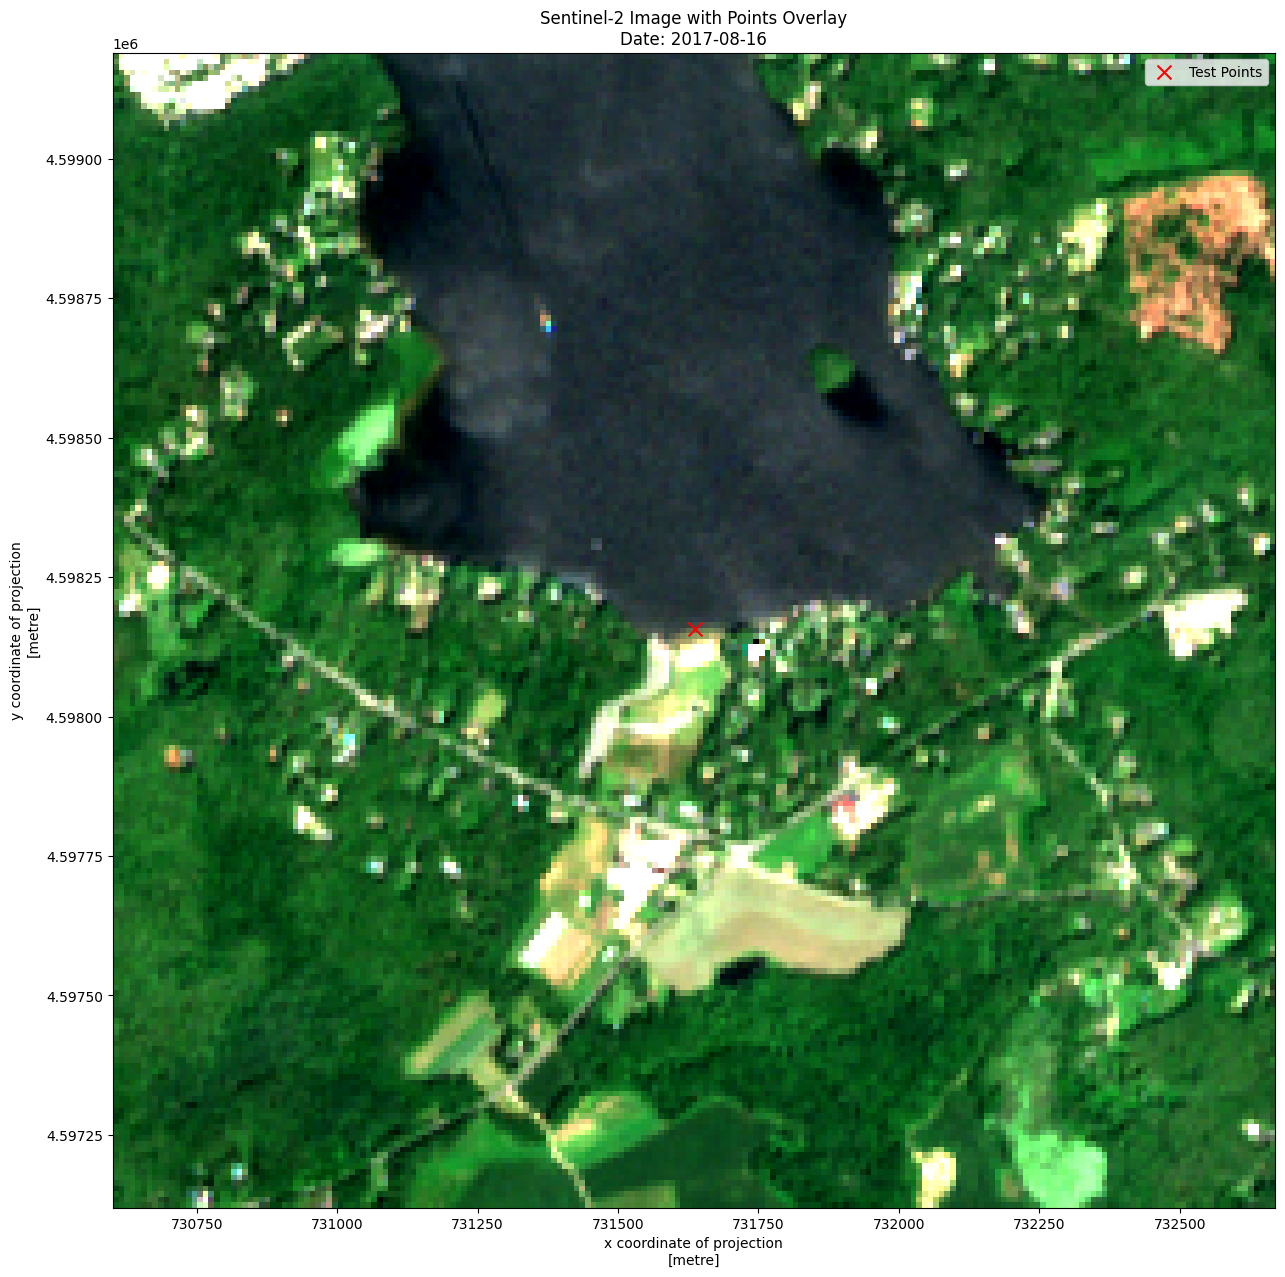

In [16]:
visual_href = pc.sign(item.assets["visual"].href)

ds = rioxarray.open_rasterio(visual_href)

bbox = get_bounding_box(p_lat, p_lon, meter_buffer=1000)

ds_clip = ds.rio.clip_box(
    minx=bbox[0], 
    miny=bbox[1], 
    maxx=bbox[2], 
    maxy=bbox[3], 
    crs="EPSG:4326" # This tells code that your bbox is in Lat/Lon
)

image_crs = ds_clip.rio.crs
transformer = Transformer.from_crs("EPSG:4326", image_crs, always_xy=True)

xx, yy = transformer.transform(test_dates.lon.values, test_dates.lat.values)

fig, ax = plt.subplots(figsize=(15, 15))

# Plot the satellite image
# robust=True handles color scaling so the image isn't too dark or bright
ds_clip.plot.imshow(ax=ax, rgb="band", robust=True)

# Plot the points on top
ax.scatter(xx, yy, c='red', s=100, marker='x', label='Test Points')

ax.set_title(f"Sentinel-2 Image with Points Overlay\nDate: {item.datetime.date()}")
plt.legend()
plt.show()

In [17]:
### Final setps

--- Starting Tile Extraction and Processing ---
Center Point (Lat/Lon): (41.5016, -72.2247)
Final Tile Dimension (10m pixels): 1024 x 1024
--- Clipping and Aligning Rasters ---
Clipped B04 (Reference): Shape (1, 1024, 1024)
Clipped B02: Shape (1, 1024, 1024)
Clipped B03: Shape (1, 1024, 1024)
Clipped B08: Shape (1, 1024, 1024)
Clipped visual: Shape (3, 1024, 1024)
Clipped AOT: Shape (1, 1024, 1024)
Clipped WVP: Shape (1, 1024, 1024)
Clipped B05: Shape (1, 1024, 1024)
Clipped B06: Shape (1, 1024, 1024)
Clipped B07: Shape (1, 1024, 1024)
Clipped B8A: Shape (1, 1024, 1024)
Clipped SCL: Shape (1, 1024, 1024)
Clipped B11: Shape (1, 1024, 1024)
Clipped B12: Shape (1, 1024, 1024)
Clipped B01: Shape (1, 1024, 1024)
Clipped B09: Shape (1, 1024, 1024)

--- Saving RAW TIFFs ---
--- Calculating Indices for Visualization ---
--- Saving Visual Previews (with markers) ---
Data successfully saved to: C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\sat data test

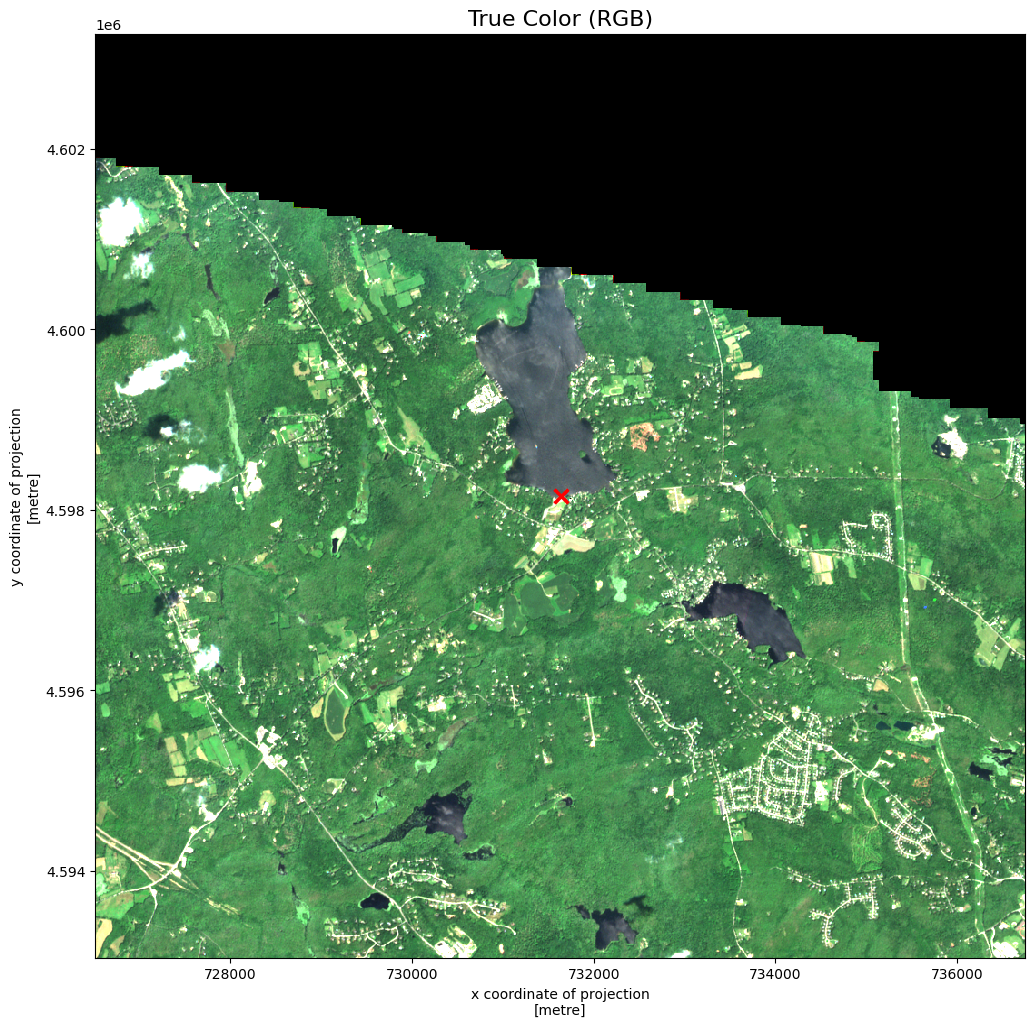

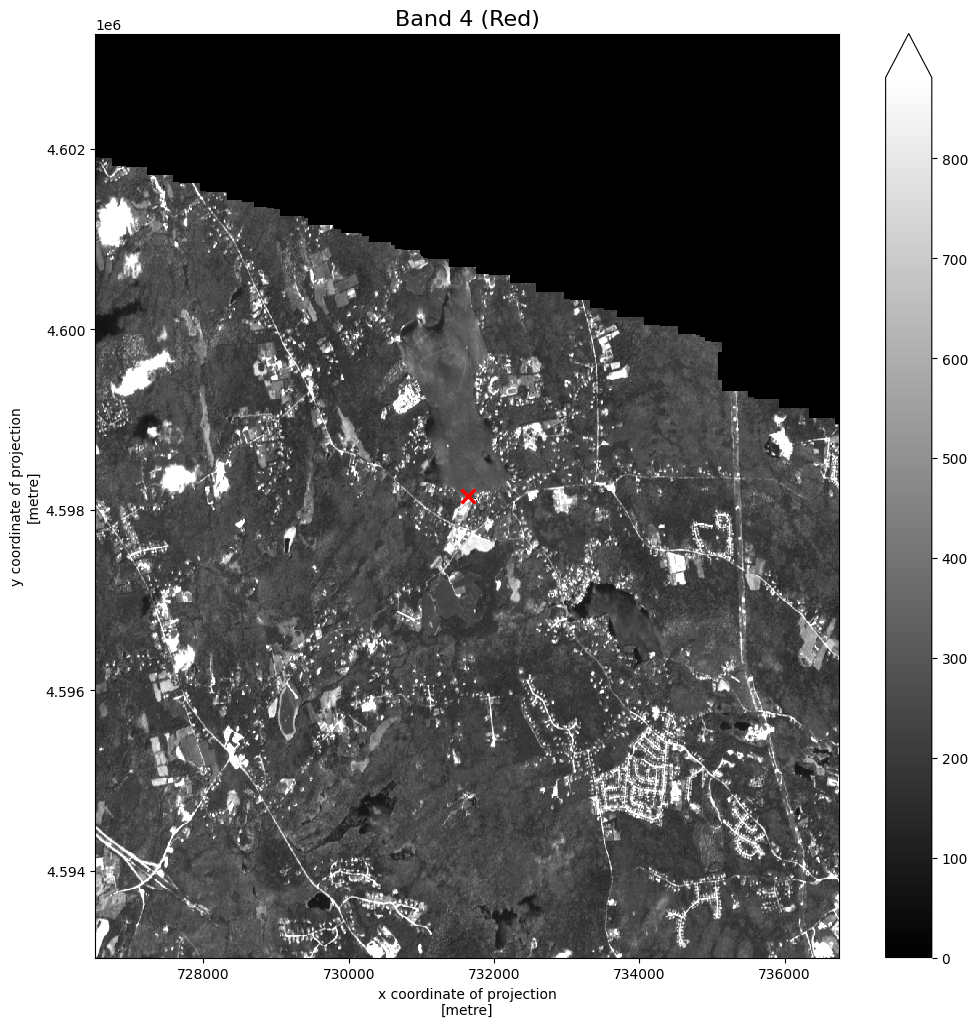

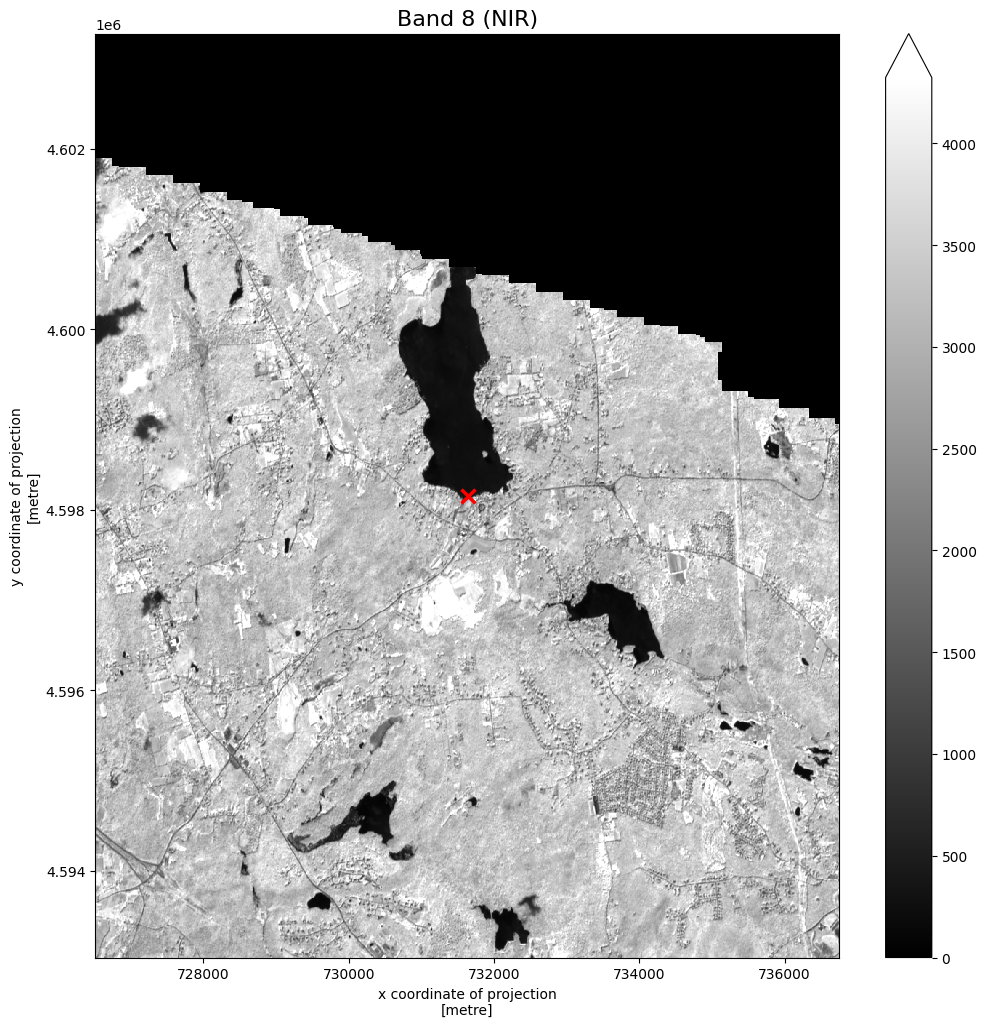

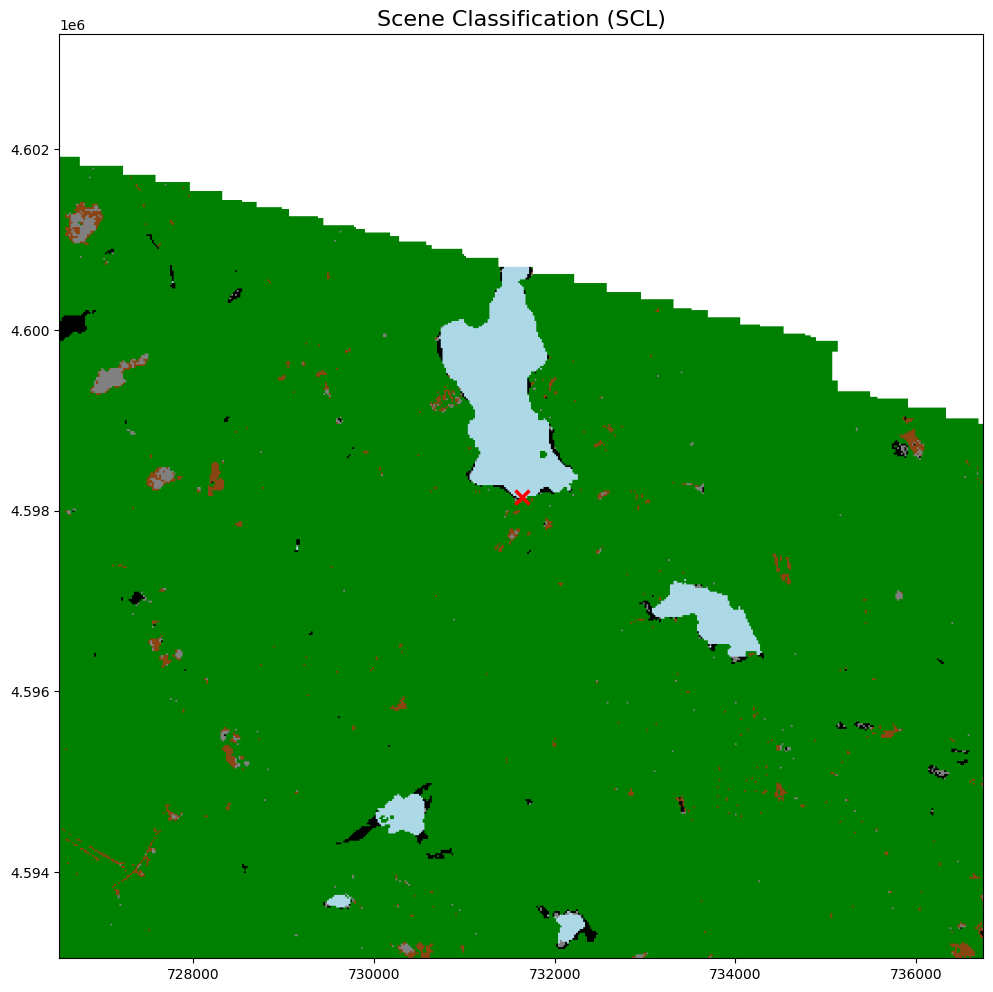

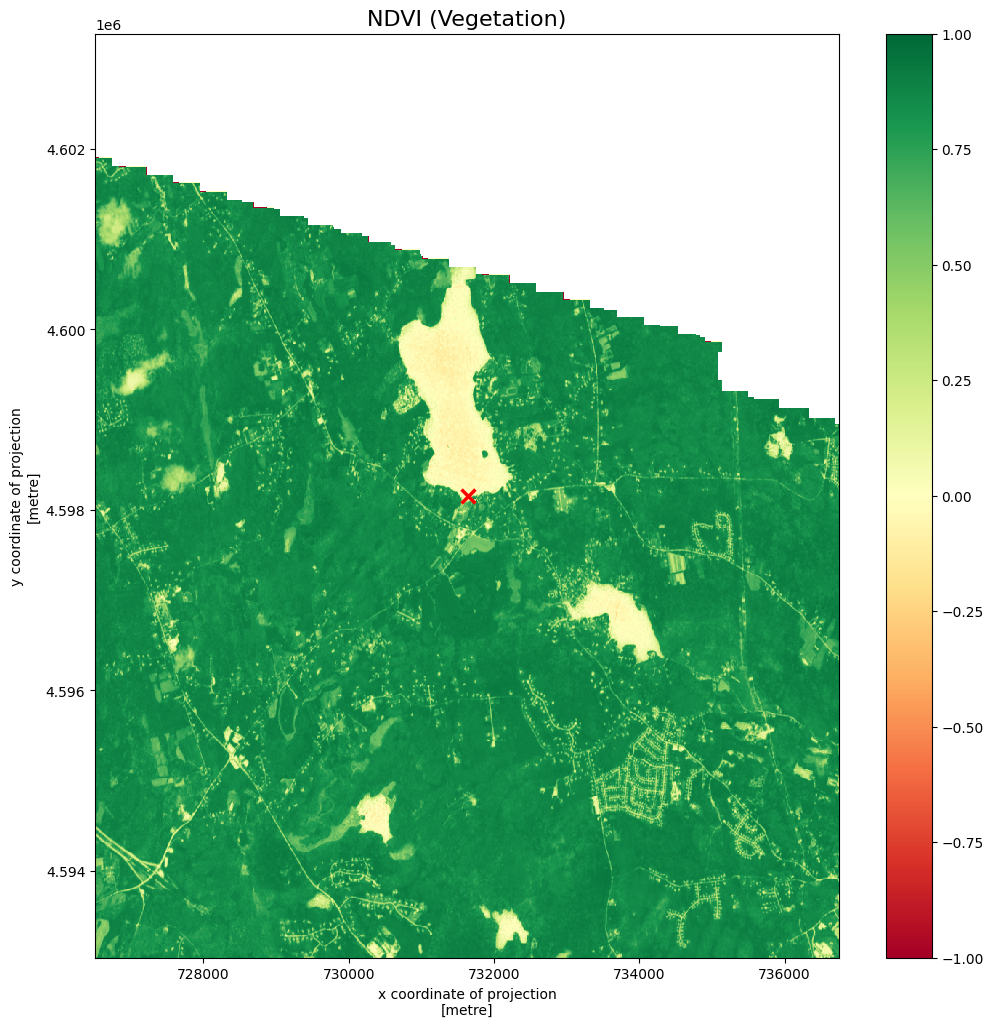

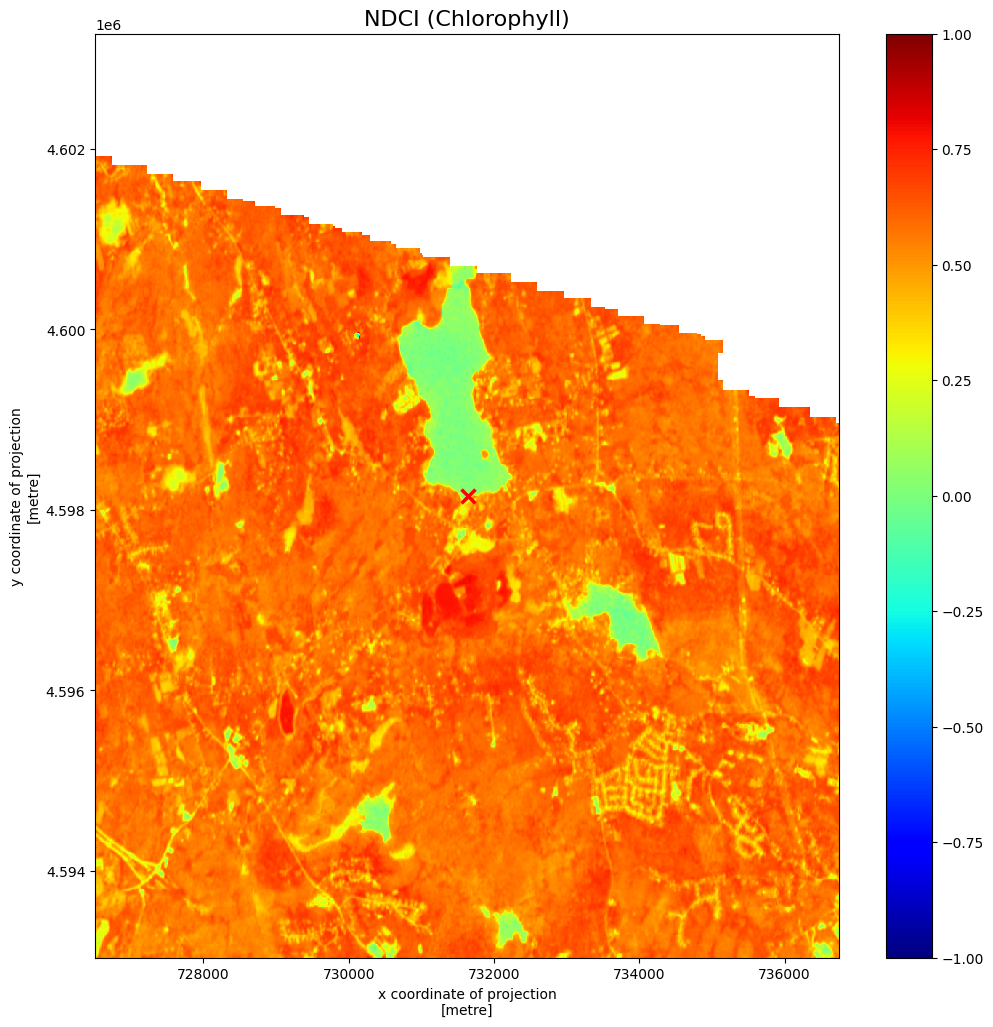

In [18]:
pixel_size = 1024
abun = str(int(max(test_dates["abun"].to_list())))
out_folder = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\sat data test\case"+str(sel_case)+"_abun"+abun+"_"+str(pixel_size)+"_date"+final_date
extract_and_save_tile(item, test_dates[['uid','abun','lat', 'lon']].copy(), initial_pixel_size=pixel_size, save_data = True, output_path = out_folder)

--- Starting CyFi Pipeline Integration (Cloud Threshold 7.5%): C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\sat data test\case8967_abun0_1024_date2017-08-16 ---
Generating 100m Lattice Grid...
Identified 271 potential water points.
Checking Cloud Cover & Slicing Data...


100%|██████████| 271/271 [00:06<00:00, 43.36it/s]
2025-12-04 17:29:18.189 | INFO     | cyfi.data.features:calculate_satellite_features:48 - Generating satellite features for 271 images.



Processing Summary:
 - Total Potential Points: 271
 - Skipped (Cloud > 7.5%): 0
 - Valid Points to Predict: 271
Running CyFi Feature Generation...


100%|██████████| 271/271 [00:06<00:00, 42.06it/s]
2025-12-04 17:29:25.644 | INFO     | cyfi.data.features:calculate_satellite_features:64 - Dropping 0 row(s) where bounding box has too many clouds.
2025-12-04 17:29:25.644 | INFO     | cyfi.data.features:calculate_satellite_features:73 - Dropping 0 row(s) where bouding box does not contain any water.
2025-12-04 17:29:25.653 | INFO     | cyfi.data.features:calculate_satellite_features:79 - Dropping 0 row(s) where bouding box contains missing pixels.
2025-12-04 17:29:25.745 | INFO     | cyfi.data.features:calculate_metadata_features:219 - Generating land cover features for 271 sample points.
100%|██████████| 271/271 [00:05<00:00, 53.76it/s] 
2025-12-04 17:29:31.827 | INFO     | cyfi.data.features:generate_all_features:317 - Generated 29 satellite feature(s) and 1 sample metadata feature(s) for 271 sample points (100% of sample points)


Running Prediction...
Predictions saved to C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\sat data test\case8967_abun0_1024_date2017-08-16\cyfi_lattice_predictions.csv
High counts :  0
Moderate counts :  6
Low counts :  265
Updated metadata saved to: C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\sat data test\case8967_abun0_1024_date2017-08-16\metadata.json
Generating Visualization...
Visualization SAVED to: C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\sat data test\case8967_abun0_1024_date2017-08-16\cyfi_prediction_map.png


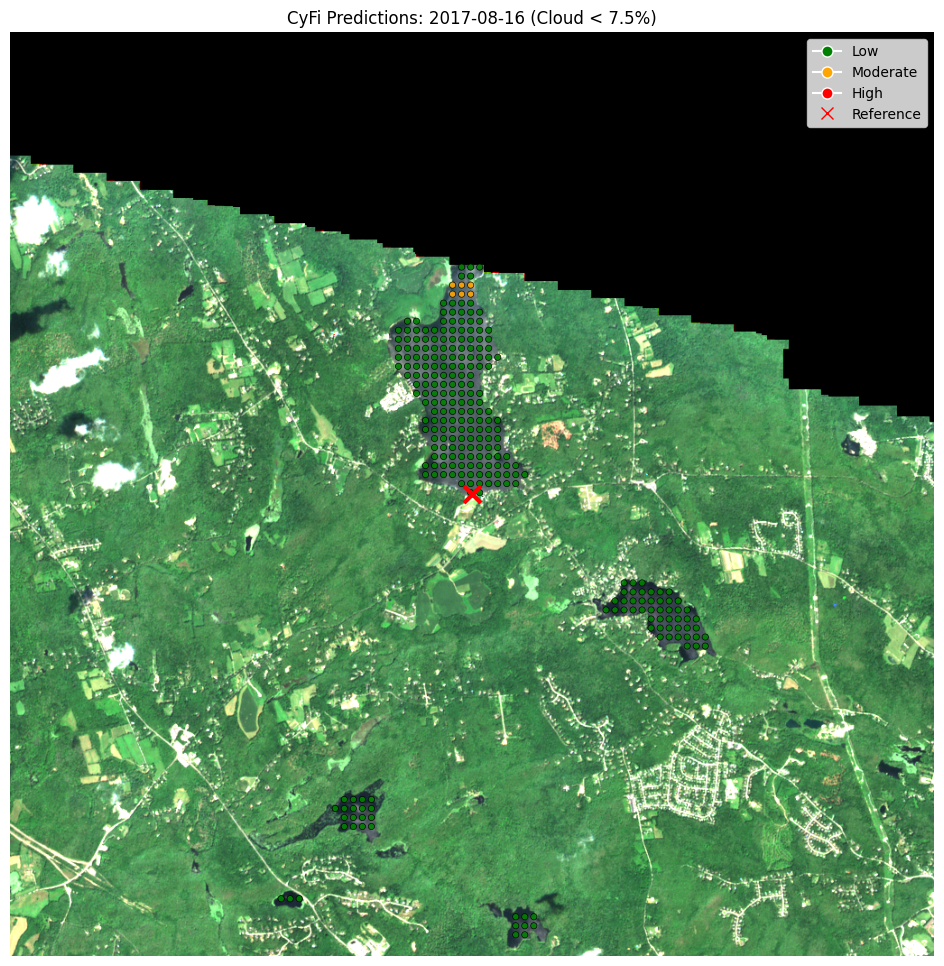

Cleaning up temporary cache...
Successfully renamed folder to: C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\sat data test\case8967_abun0_1024_date2017-08-16_H0_M6_L265
Done!


In [19]:
folder_ok, new_path = predict_using_cyfi_pipeline(out_folder, final_date)

In [23]:
update_excel_report(new_path, r"C:/Users/KostasPikounis/OneDrive_Inlecom_Personal/OneDrive - INLECOM/Amfitrite/task2/IWD/sat data test/Master_Report.xlsx")

--- Updating Report (Rebuild Strategy): C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\sat data test\Master_Report.xlsx ---
Report Rebuilt Successfully: C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\sat data test\Master_Report.xlsx
